# Process Single Table

In [1]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration pour afficher les graphiques dans le notebook
%matplotlib inline
plt.style.use('ggplot')
sns.set(style='whitegrid')

In [2]:
# Load the dataset
df = pd.read_csv('Datasets/Tabular/Time_series/dataset_time_series.csv')

# Display basic information
print("Table shape:", df.shape)
print("Column names:", df.columns.tolist())
df.head()


Table shape: (9990, 13)
Column names: ['Unnamed: 0', 'ID', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5', 'Feature_6', 'Feature_7', 'Feature_8', 'Feature_9', 'Feature_10', 'Target']


,Unnamed: 0,ID,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Target
0,10,11,-0.221708,1.133047,1.352241,-0.124647,4.017140,1.836551,-0.478149,2.074969,2.129173,-0.232051,2.304265
1,11,12,-0.221864,1.196557,1.308560,-0.850371,4.322888,2.102496,-0.969116,-2.437057,1.455233,0.441201,0.452407
2,12,13,0.132982,0.630783,0.991719,-0.564366,3.008537,2.650296,0.899033,-4.669752,1.825879,-0.501489,2.858446
3,13,14,-0.943639,0.969822,0.903074,-0.188469,2.034749,2.821024,0.170669,-4.823012,1.980669,-0.103675,2.468120
4,14,15,-0.848458,1.440260,1.624604,-1.532611,0.911643,2.157261,-0.214645,-0.074111,2.073125,0.239503,2.280645


In [3]:
# Transform categorical columns to numerical
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for col in df.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
df.head()


,Unnamed: 0,ID,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Target
0,10,11,-0.221708,1.133047,1.352241,-0.124647,4.017140,1.836551,-0.478149,2.074969,2.129173,-0.232051,2.304265
1,11,12,-0.221864,1.196557,1.308560,-0.850371,4.322888,2.102496,-0.969116,-2.437057,1.455233,0.441201,0.452407
2,12,13,0.132982,0.630783,0.991719,-0.564366,3.008537,2.650296,0.899033,-4.669752,1.825879,-0.501489,2.858446
3,13,14,-0.943639,0.969822,0.903074,-0.188469,2.034749,2.821024,0.170669,-4.823012,1.980669,-0.103675,2.468120
4,14,15,-0.848458,1.440260,1.624604,-1.532611,0.911643,2.157261,-0.214645,-0.074111,2.073125,0.239503,2.280645


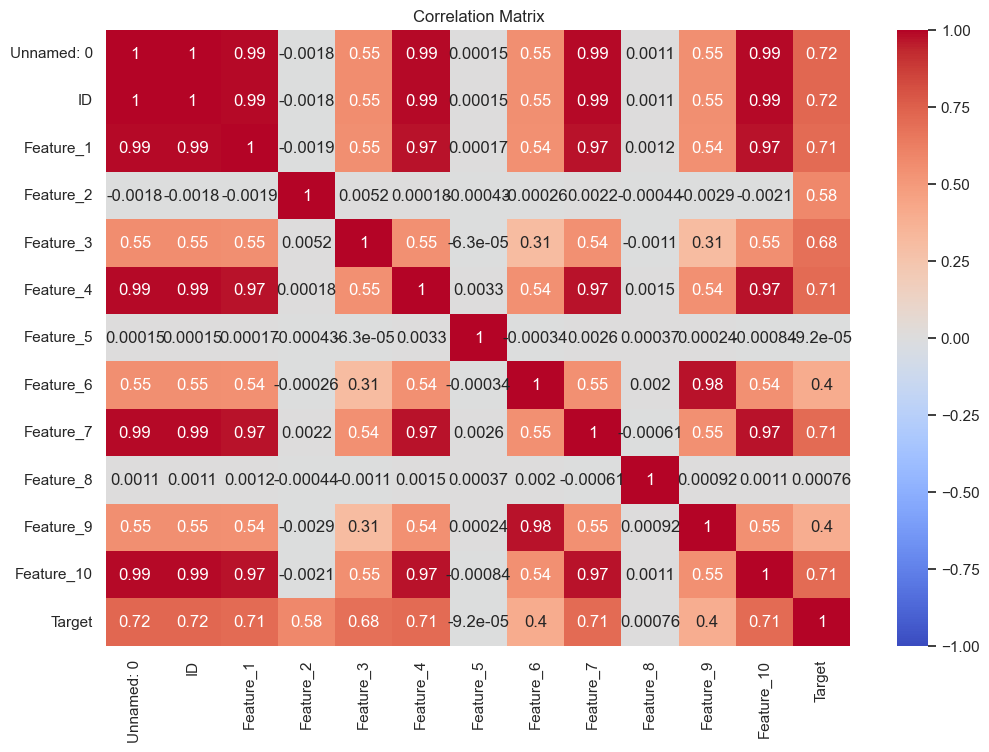

In [4]:
# Display correlation matrix
corr_matrix = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()


# LSTM

In [5]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader


In [6]:
target_column = "Target"

# Check for any missing values
print(f"Missing values in dataset: {df.isna().sum().sum()}")

# Remove non-feature columns if they exist
features_to_drop = []
for col in df.columns:
    if col != target_column and (col == 'ID' or col == 'Date' or 'Unnamed' in col):
        features_to_drop.append(col)

if features_to_drop:
    print(f"Dropping non-feature columns: {features_to_drop}")
    df = df.drop(columns=features_to_drop)

# Split into features and target
X = df.drop(columns=[target_column])
y = df[target_column]

# Scale features - critical for LSTM performance
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# Scale target for better training stability
y_mean = y.mean()
y_std = y.std()
print(f"Target statistics - Mean: {y_mean:.4f}, Std: {y_std:.4f}")
y_scaled = (y - y_mean) / y_std

# Function to create sequences for time series forecasting
def create_sequences(X, y, seq_length):
    xs, ys = [], []
    for i in range(len(X) - seq_length):
        xs.append(X[i:i+seq_length])
        ys.append(y[i+seq_length])
    return np.array(xs), np.array(ys)

# Define sequence length for LSTM
seq_length = 10  # Number of time steps to look back

# Create sequences
X_seq, y_seq = create_sequences(X_scaled, y_scaled, seq_length)
print(f"Sequence shapes: X = {X_seq.shape}, y = {y_seq.shape}")

# Split into training and test sets - time order matters for time series
train_size = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:train_size], X_seq[train_size:]
y_train, y_test = y_seq[:train_size], y_seq[train_size:]

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)

print(f"Training data: X = {X_train_tensor.shape}, y = {y_train_tensor.shape}")
print(f"Test data: X = {X_test_tensor.shape}, y = {y_test_tensor.shape}")


Missing values in dataset: 0
Dropping non-feature columns: ['Unnamed: 0', 'ID']
Target statistics - Mean: 19.6674, Std: 15.5944
Sequence shapes: X = (9980, 10, 10), y = (9980,)
Training data: X = torch.Size([7984, 10, 10]), y = torch.Size([7984, 1])
Test data: X = torch.Size([1996, 10, 10]), y = torch.Size([1996, 1])


In [7]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM with multiple layers and dropout
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        
        # Fully connected layers with activation and dropout
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_size // 2, 1)
        
    def forward(self, x):
        # Initialize hidden state with zeros
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        
        # Forward propagate LSTM
        lstm_out, _ = self.lstm(x, (h0, c0))
        
        # Use output from the last time step
        out = self.fc1(lstm_out[:, -1, :])
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        
        return out


In [8]:
# Model configuration
input_size = X_train.shape[2]  # Number of features
hidden_size = 128
num_layers = 2
dropout = 0.2

# Create the model
model = LSTMModel(input_size, hidden_size, num_layers, dropout)
print(model)

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# Create DataLoader for batch training
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)


LSTMModel(
  (lstm): LSTM(10, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


In [9]:
# Training parameters
num_epochs = 200
best_loss = float('inf')
patience = 15
counter = 0
train_losses = []
val_losses = []

# Training loop
for epoch in range(num_epochs):
    # Training phase
    model.train()
    epoch_loss = 0
    
    for batch_X, batch_y in train_loader:
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
    
    # Average loss for the epoch
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation phase
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor)
        val_losses.append(val_loss.item())
        
        # Update learning rate
        scheduler.step(val_loss)
        
        # Early stopping check
        if val_loss < best_loss:
            best_loss = val_loss
            counter = 0
            # Save the best model
            torch.save(model.state_dict(), 'Output/best_lstm_model.pth')
        else:
            counter += 1
    
    if counter >= patience:
        print(f'Early stopping triggered at epoch {epoch+1}')
        break
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss.item():.4f}')

# Load the best model
model.load_state_dict(torch.load('Output/best_lstm_model.pth'))


Epoch [10/200], Train Loss: 0.0150, Val Loss: 0.0165


Epoch [20/200], Train Loss: 0.0131, Val Loss: 0.0108


Epoch [30/200], Train Loss: 0.0132, Val Loss: 0.0100


Epoch [40/200], Train Loss: 0.0121, Val Loss: 0.0109


Epoch [50/200], Train Loss: 0.0118, Val Loss: 0.0103


Epoch [60/200], Train Loss: 0.0116, Val Loss: 0.0086


Epoch [70/200], Train Loss: 0.0116, Val Loss: 0.0087


Early stopping triggered at epoch 78


<All keys matched successfully>

In [10]:
# Evaluate the model
model.eval()
with torch.no_grad():
    # Make predictions
    test_predictions = model(X_test_tensor)
    
    # Convert to numpy and rescale back to original units
    y_pred_scaled = test_predictions.numpy().flatten()
    y_true_scaled = y_test_tensor.numpy().flatten()
    
    # Convert predictions back to original scale
    y_pred = y_pred_scaled * y_std + y_mean
    y_true = y_true_scaled * y_std + y_mean
    
    # Calculate metrics
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f'MSE: {mse:.4f}')
    print(f'RMSE: {rmse:.4f}')
    print(f'MAE: {mae:.4f}')
    print(f'R² Score: {r2:.4f}')

MSE: 1.9260
RMSE: 1.3878
MAE: 1.0476
R² Score: 0.9846
